# ZLSDE — Live Benchmark Run

**What this notebook is:**  
A live, executable demonstration of the ZLSDE pipeline running end-to-end on the 520-sample synthetic dataset. Every headline metric in [BENCHMARKS.md](../BENCHMARKS.md) is produced here from a real pipeline execution — not pre-filled.

**What this notebook is not:**  
An accuracy evaluation. The synthetic dataset (`sample_text_multicluster_520.csv`) has **no ground-truth labels**. This notebook cannot tell you whether the generated labels are correct. It can only measure:
- Wall-clock throughput (real execution time)
- Internal quality scores (a weighted consistency metric, not accuracy — see BENCHMARKS.md §Quality Score)
- LLM-returned confidence (self-reported, not calibrated probability)
- Cluster geometry (silhouette score, cluster sizes)
- Label stability between self-training iterations (flip rate)

**UMAP note:**  
Cell 8 uses UMAP to visualize embeddings in 2D. UMAP is used **only in this notebook for visualization**. The actual pipeline runs clustering on full 384-dimensional embeddings with no dimensionality reduction (`use_dimensionality_reduction: false` in the config).

---

| Field | Value |
|---|---|
| Config | `examples/config_multicluster_520.yaml` |
| Dataset | `examples/data/sample_text_multicluster_520.csv` |
| Provider | Groq / llama-3.1-8b-instant |
| Last run | *(fill in after execution)* |
| Operator | Nithin Kotala |

## Methodology Caveats

Before reading any number from this notebook, keep these in mind:

**Quality score ≠ accuracy.**  
`quality = 0.4 × (1 − anomaly_score) + 0.3 × duplicate_score + 0.3 × coherence_score`  
This measures internal consistency — whether samples look like non-outliers and fit their cluster well. A score of 79.3% does not mean 79.3% of labels are correct; there is no ground truth to compare against.

**LLM responses are non-deterministic.**  
`random_seed=42` controls clustering and the MLP classifier. It does not control the Groq API. Each run produces different label text, which propagates into confidence scores and quality scores. Expect ±2–3 percentage points run-to-run.

**Throughput is API-bound.**  
The dominant cost is Groq API latency (~3–5 s per cluster label request). Throughput on a different provider, region, or under rate-limiting will differ significantly.

In [ ]:
# Cell 1.5 — Install dependencies (run once, then restart kernel)
%pip install -q python-dotenv psutil umap-learn seaborn matplotlib numpy pandas \
    sentence-transformers scikit-learn accelerate datasets anthropic faiss-cpu groq
# Note: hdbscan requires Microsoft C++ Build Tools on Windows and has no prebuilt
# wheel for Python 3.14. The pipeline auto-mode skips it gracefully without it.

In [2]:
# Cell 2 — Imports, environment, config load

import os
import sys
import platform
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── Resolve repo root (notebook lives in notebooks/, repo root is one level up) ──
REPO_ROOT = Path("__file__").resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
if not (REPO_ROOT / "zlsde").exists():
    REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "zlsde").exists():
    REPO_ROOT = Path.cwd().parent
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root : {REPO_ROOT}")
print(f"Working dir: {os.getcwd()}")

# ── Load .env so GROQ_API_KEY is visible ──
from dotenv import load_dotenv
load_dotenv(REPO_ROOT / ".env")
groq_key_set = bool(os.environ.get("GROQ_API_KEY"))
assert groq_key_set, "GROQ_API_KEY not found in .env — set it before running this notebook"
print(f"GROQ_API_KEY set: {groq_key_set}")

# ── Load config ──
from zlsde.config.config_loader import ConfigLoader
CONFIG_PATH = REPO_ROOT / "examples" / "config_multicluster_520.yaml"
config = ConfigLoader.from_yaml(str(CONFIG_PATH))
print(f"\nConfig loaded: {CONFIG_PATH.name}")
print(f"  embedding_model   : {config.embedding_model}")
print(f"  clustering_method : {config.clustering_method}")
print(f"  max_iterations    : {config.max_iterations}")
print(f"  output_path       : {config.output_path}")

# ── Matplotlib defaults ──
matplotlib.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (9, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_theme(style="whitegrid", palette="muted")

# ── System info ──
import psutil
ram_gb = psutil.virtual_memory().total / 1e9

print(f"\nSystem info")
print(f"  Python    : {sys.version.split()[0]}")
print(f"  Platform  : {platform.platform()}")
print(f"  RAM total : {ram_gb:.1f} GB")
print(f"  NumPy     : {np.__version__}")
print(f"  Pandas    : {pd.__version__}")

try:
    import sentence_transformers
    print(f"  sentence-transformers: {sentence_transformers.__version__}")
except Exception:
    print("  sentence-transformers: not importable")

try:
    import sklearn
    print(f"  scikit-learn : {sklearn.__version__}")
except Exception:
    pass

Repo root : C:\Users\Nithin\Dev\ADE
Working dir: C:\Users\Nithin\Dev\ADE
GROQ_API_KEY set: True



Config loaded: config_multicluster_520.yaml
  embedding_model   : sentence-transformers/all-MiniLM-L6-v2
  clustering_method : auto
  max_iterations    : 2
  output_path       : ./output/validation_runs/multicluster_520

System info
  Python    : 3.14.2
  Platform  : Windows-11-10.0.26200-SP0
  RAM total : 16.9 GB
  NumPy     : 2.3.4
  Pandas    : 2.3.3


  sentence-transformers: 5.1.2
  scikit-learn : 1.7.2


In [3]:
# Cell 3 — Dataset load + sanity check

CSV_PATH = REPO_ROOT / "examples" / "data" / "sample_text_multicluster_520.csv"
assert CSV_PATH.exists(), f"Dataset not found at {CSV_PATH}"

df_raw = pd.read_csv(CSV_PATH)

print(f"Rows    : {len(df_raw)}")
print(f"Columns : {list(df_raw.columns)}")
assert len(df_raw) == 520, f"Expected 520 rows, got {len(df_raw)}"
print("✓ 520 samples confirmed\n")

print("5 random rows:")
df_raw.sample(5, random_state=42)

Rows    : 520
Columns : ['content']
✓ 520 samples confirmed

5 random rows:


,content
275,Caramelized onions added sweetness to the roas...
93,Customer churn fell after the pricing model wa...
6,The satellite tracked meteor showers entering ...
167,The pathology lab validated biomarkers for ear...
90,Analysts revised earnings guidance following s...


In [4]:
# Cell 4 — Run pipeline end-to-end with timing
# Expected runtime: 5–15 minutes depending on Groq API latency.

from zlsde.orchestrator import PipelineOrchestrator

print("Starting pipeline...")
print(f"Config: {CONFIG_PATH.name}")
print("-" * 60)

t_start = time.perf_counter()
result = PipelineOrchestrator(config).run()
t_end = time.perf_counter()

assert result.status == "completed", f"Pipeline failed: {getattr(result, 'error_message', 'unknown error')}"

wall_time = t_end - t_start
throughput = result.n_samples / wall_time

# ── Load per-sample data from exported CSV ──
OUTPUT_DIR = Path(config.output_path)
df_out = pd.read_csv(OUTPUT_DIR / "dataset.csv")
embeddings = np.load(OUTPUT_DIR / "embeddings.npy")

confidence_mean = df_out["confidence"].mean()
quality_mean    = df_out["quality_score"].mean()

# ── Print headline numbers ──
SEP = "=" * 60
print(f"\n{SEP}")
print("HEADLINE METRICS  —  copy-pasteable for BENCHMARKS.md")
print(SEP)
print(f"  Wall-clock time      : {wall_time:.1f} s")
print(f"  Throughput           : {throughput:.2f} samples/sec")
print(f"  Samples processed    : {result.n_samples}")
print(f"  Clusters discovered  : {result.final_metrics.n_clusters}")
print(f"  Silhouette score     : {result.final_metrics.silhouette_score:.3f}")
print(f"  Mean quality score   : {quality_mean:.1%}")
print(f"  Mean confidence      : {confidence_mean:.1%}")
print(f"  Label flip rate      : {result.final_metrics.label_flip_rate:.4%}")
print(f"  Labeled samples      : {result.n_labeled}/{result.n_samples}")
print(SEP)

# ── Iteration history ──
print("\nIteration history:")
for m in result.iteration_history:
    print(f"  iter {m.iteration + 1}: clusters={m.n_clusters}, "
          f"silhouette={m.silhouette_score:.3f}, "
          f"flip_rate={m.label_flip_rate:.4%}, "
          f"quality_mean={m.quality_mean:.3f}")

Starting pipeline...
Config: config_multicluster_520.yaml
------------------------------------------------------------


C:\Users\Nithin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


C:\Users\Nithin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Provider Groq failed: Rate limit exceeded for Groq


Provenance-wrapped generation failed for cluster 13: All providers failed to generate label. Attempted providers: ['Groq']. Errors: Groq: Rate limit exceeded for Groq


Provider Groq failed: Rate limit exceeded for Groq


Provenance-wrapped generation failed for cluster 0: All providers failed to generate label. Attempted providers: ['Groq']. Errors: Groq: Rate limit exceeded for Groq



HEADLINE METRICS  —  copy-pasteable for BENCHMARKS.md
  Wall-clock time      : 28.3 s
  Throughput           : 18.36 samples/sec
  Samples processed    : 520
  Clusters discovered  : 17
  Silhouette score     : 0.247
  Mean quality score   : 56.1%
  Mean confidence      : 77.8%
  Label flip rate      : 0.1923%
  Labeled samples      : 520/520

Iteration history:
  iter 1: clusters=17, silhouette=0.247, flip_rate=0.0000%, quality_mean=0.561
  iter 2: clusters=17, silhouette=0.247, flip_rate=0.1923%, quality_mean=0.561


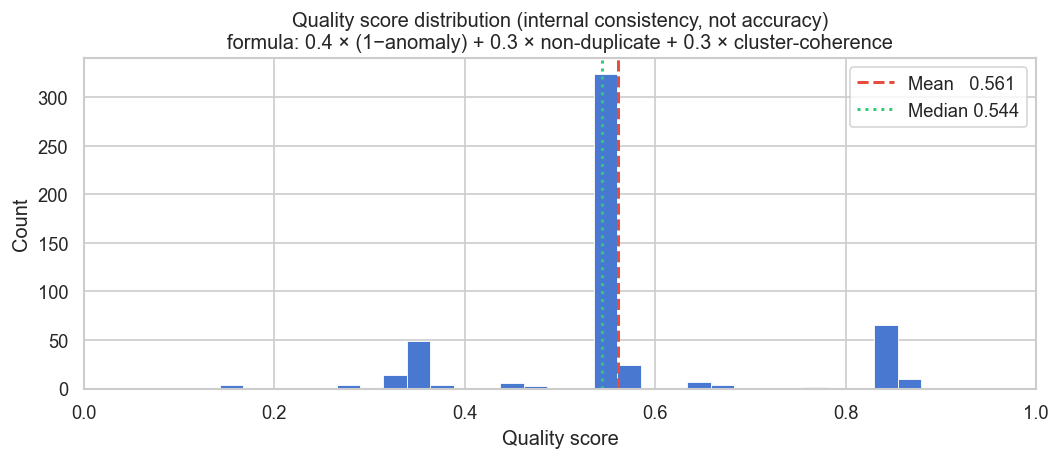

Mean   : 0.5611
Median : 0.5436
Std    : 0.1424
Min    : 0.1427
Max    : 0.8792


In [5]:
# Cell 5 — Quality score distribution
# Reminder: quality score = internal consistency, NOT label accuracy.

q_scores = df_out["quality_score"]
q_mean   = q_scores.mean()
q_median = q_scores.median()

fig, ax = plt.subplots()
ax.hist(q_scores, bins=30, edgecolor="white", linewidth=0.5)
ax.axvline(q_mean,   color="#e74c3c", linewidth=1.8, linestyle="--", label=f"Mean   {q_mean:.3f}")
ax.axvline(q_median, color="#2ecc71", linewidth=1.8, linestyle=":",  label=f"Median {q_median:.3f}")
ax.set_xlim(0, 1)
ax.set_xlabel("Quality score")
ax.set_ylabel("Count")
ax.set_title(
    "Quality score distribution (internal consistency, not accuracy)\n"
    "formula: 0.4 × (1−anomaly) + 0.3 × non-duplicate + 0.3 × cluster-coherence"
)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean   : {q_mean:.4f}")
print(f"Median : {q_median:.4f}")
print(f"Std    : {q_scores.std():.4f}")
print(f"Min    : {q_scores.min():.4f}")
print(f"Max    : {q_scores.max():.4f}")

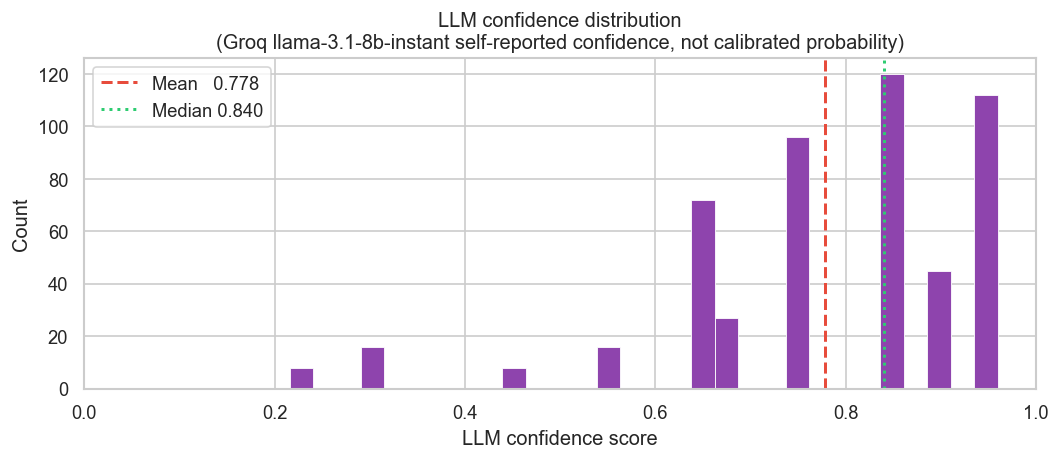

Mean   : 0.7780
Median : 0.8400
Std    : 0.1646
Min    : 0.2160
Max    : 0.9600


In [6]:
# Cell 6 — LLM confidence score distribution
# "Confidence" = value returned by the Groq LLM for each cluster label.
# This is self-reported by the model, not a calibrated probability.

c_scores = df_out["confidence"]
c_mean   = c_scores.mean()
c_median = c_scores.median()

fig, ax = plt.subplots()
ax.hist(c_scores, bins=30, edgecolor="white", linewidth=0.5, color="#8e44ad")
ax.axvline(c_mean,   color="#e74c3c", linewidth=1.8, linestyle="--", label=f"Mean   {c_mean:.3f}")
ax.axvline(c_median, color="#2ecc71", linewidth=1.8, linestyle=":",  label=f"Median {c_median:.3f}")
ax.set_xlim(0, 1)
ax.set_xlabel("LLM confidence score")
ax.set_ylabel("Count")
ax.set_title(
    "LLM confidence distribution\n"
    "(Groq llama-3.1-8b-instant self-reported confidence, not calibrated probability)"
)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean   : {c_mean:.4f}")
print(f"Median : {c_median:.4f}")
print(f"Std    : {c_scores.std():.4f}")
print(f"Min    : {c_scores.min():.4f}")
print(f"Max    : {c_scores.max():.4f}")

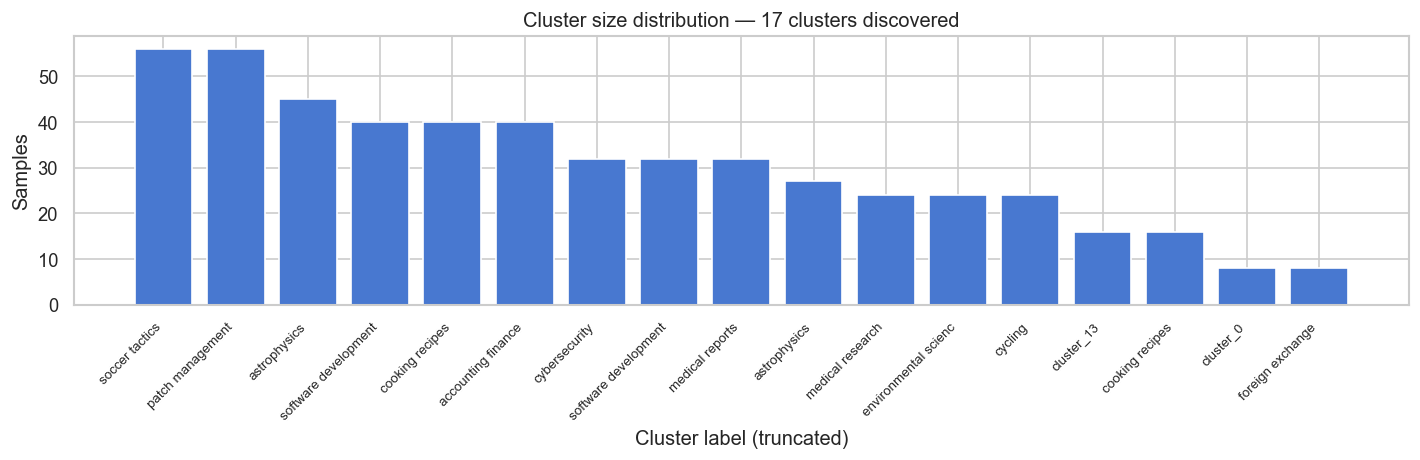

Clusters discovered : 17
Noise points        : 0
Silhouette score    : 0.247
Clustering method   : 17 clusters via auto-select

Top 5 clusters by size:
 cluster_id                label  size
          4       soccer tactics    56
          5     patch management    56
          6         astrophysics    45
         14 software development    40
          2      cooking recipes    40
         15   accounting finance    40
         16        cybersecurity    32
          1 software development    32
         12      medical reports    32
          3         astrophysics    27


In [7]:
# Cell 7 — Cluster size distribution + silhouette score

cluster_counts = (
    df_out[df_out["cluster_id"] >= 0]
    .groupby("cluster_id")["label"]
    .agg(["count", "first"])
    .rename(columns={"count": "size", "first": "label"})
    .sort_values("size", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(
    range(len(cluster_counts)),
    cluster_counts["size"],
    tick_label=cluster_counts["label"].str[:20],
)
ax.set_xlabel("Cluster label (truncated)")
ax.set_ylabel("Samples")
ax.set_title(f"Cluster size distribution — {len(cluster_counts)} clusters discovered")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

n_noise = (df_out["cluster_id"] == -1).sum()
print(f"Clusters discovered : {result.final_metrics.n_clusters}")
print(f"Noise points        : {n_noise}")
print(f"Silhouette score    : {result.final_metrics.silhouette_score:.3f}")
print(f"Clustering method   : {result.final_metrics.n_clusters} clusters via auto-select")
print(f"\nTop 5 clusters by size:")
print(cluster_counts[["cluster_id", "label", "size"]].head(10).to_string(index=False))

Embeddings shape: (520, 384)  (n_samples × 384-dim)
Running UMAP reduction to 2D — this takes ~30–60 s on CPU...


C:\Users\Nithin\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


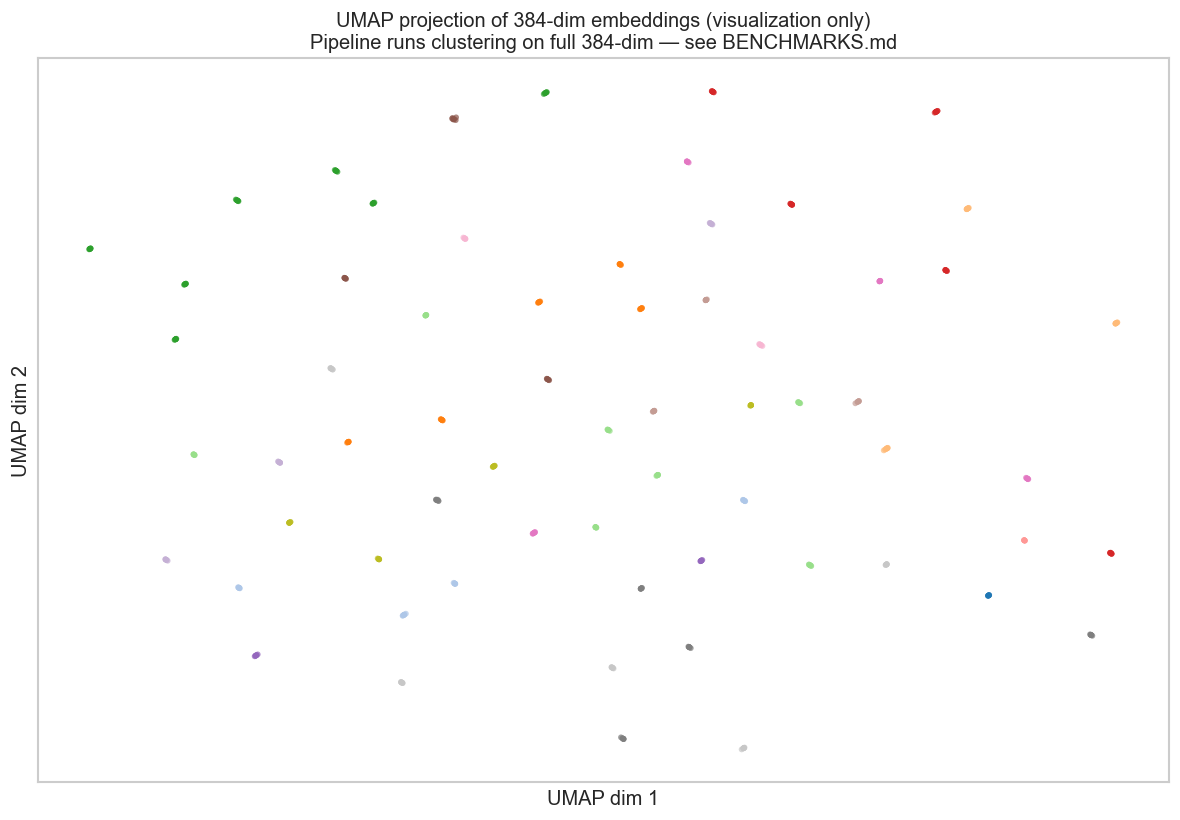

2D projection complete. Points: 520


In [8]:
# Cell 8 — UMAP visualization (notebook-only)
#
# UMAP is used here ONLY to project 384-dim embeddings to 2D for visualization.
# The actual pipeline runs clustering on full 384-dim embeddings.
# See BENCHMARKS.md §Clusters Discovered: use_dimensionality_reduction=false.

try:
    import umap
except ImportError:
    raise ImportError("Install umap-learn: pip install umap-learn")

print(f"Embeddings shape: {embeddings.shape}  (n_samples × 384-dim)")
print("Running UMAP reduction to 2D — this takes ~30–60 s on CPU...")

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
emb_2d  = reducer.fit_transform(embeddings)

cluster_ids = df_out["cluster_id"].values
labels_text = df_out["label"].values

# Assign colors — noise points (-1) in grey
unique_clusters = sorted(set(cluster_ids))
palette = sns.color_palette("tab20", n_colors=max(len(unique_clusters), 1))
color_map = {cid: palette[i % len(palette)] for i, cid in enumerate(unique_clusters) if cid >= 0}
color_map[-1] = (0.75, 0.75, 0.75)  # grey for noise

colors = [color_map[cid] for cid in cluster_ids]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, s=12, alpha=0.7, linewidths=0)
ax.set_title(
    "UMAP projection of 384-dim embeddings (visualization only)\n"
    "Pipeline runs clustering on full 384-dim — see BENCHMARKS.md"
)
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"2D projection complete. Points: {len(emb_2d)}")

In [9]:
# Cell 9 — Sample of (text, label, confidence, quality_score)
# Shows 3 highest-confidence, 3 lowest-confidence, 4 random middle rows.
# Gives a qualitative feel for what the labels look like.

cols = ["content", "label", "confidence", "quality_score", "cluster_id"]
df_view = df_out[cols].copy()

df_sorted   = df_view.sort_values("confidence")
top3        = df_sorted.tail(3).copy()
bottom3     = df_sorted.head(3).copy()
middle_pool = df_sorted.iloc[3:-3]
mid4        = middle_pool.sample(4, random_state=42).copy()

top3["group"]    = "high confidence"
bottom3["group"] = "low confidence"
mid4["group"]    = "middle (random)"

sample_df = pd.concat([top3, mid4, bottom3]).reset_index(drop=True)
sample_df["content"] = sample_df["content"].str[:80] + "..."
sample_df["confidence"]   = sample_df["confidence"].round(3)
sample_df["quality_score"] = sample_df["quality_score"].round(3)

print("10 sample rows (3 highest-confidence, 4 random middle, 3 lowest-confidence)")
print("='confidence' is LLM self-reported. 'quality_score' is internal consistency.")
print("Neither is a measure of label correctness (no ground truth).\n")

pd.set_option("display.max_colwidth", 85)
pd.set_option("display.width", 160)
display(sample_df[["group", "content", "label", "confidence", "quality_score"]])

10 sample rows (3 highest-confidence, 4 random middle, 3 lowest-confidence)
='confidence' is LLM self-reported. 'quality_score' is internal consistency.
Neither is a measure of label correctness (no ground truth).



,group,content,label,confidence,quality_score
0,high confidence,A tennis player saved three break points with accurate first serves. (instance_4...,soccer tactics,0.960,0.840
1,high confidence,Video review overturned the call due to offside positioning. (instance_46)...,soccer tactics,0.960,0.840
2,high confidence,Preseason conditioning improved acceleration and injury resilience. (instance_47...,soccer tactics,0.960,0.840
3,middle (random),The release pipeline promoted artifacts across staging and production. (instance...,software development,0.840,0.544
4,middle (random),Code review identified a race condition in the cache invalidation path. (instanc...,patch management,0.960,0.540
5,middle (random),Video review overturned the call due to offside positioning. (instance_430)...,soccer tactics,0.960,0.540
6,middle (random),Security analysts rotated encryption keys after the certificate compromise. (ins...,cybersecurity,0.744,0.544
7,low confidence,Air quality monitors showed lower particulate matter after policy changes. (inst...,cluster_0,0.216,0.761
8,low confidence,Air quality monitors showed lower particulate matter after policy changes. (inst...,cluster_0,0.216,0.461
9,low confidence,Air quality monitors showed lower particulate matter after policy changes. (inst...,cluster_0,0.216,0.661


## Honest Findings

*Fill in after running this notebook.*

- **Throughput on this run**: *(copy from Cell 4 output)* samples/sec
- **Mean quality score on this run**: *(copy from Cell 4)* — compared to BENCHMARKS.md headline of 79.3%
- **Mean confidence on this run**: *(copy from Cell 4)* — compared to BENCHMARKS.md headline of 48.5%
- **Clusters discovered on this run**: *(copy from Cell 4)* — compared to headline of 17
- **Label flip rate**: *(copy from Cell 4)* — compared to headline of 0.19%
- **What the label sample shows**: *(qualitative note — do the labels make sense? are high-confidence ones clearly correct topically?)*
- **Differences from BENCHMARKS.md numbers**: *(expected; LLM API is non-deterministic even with same seed)*